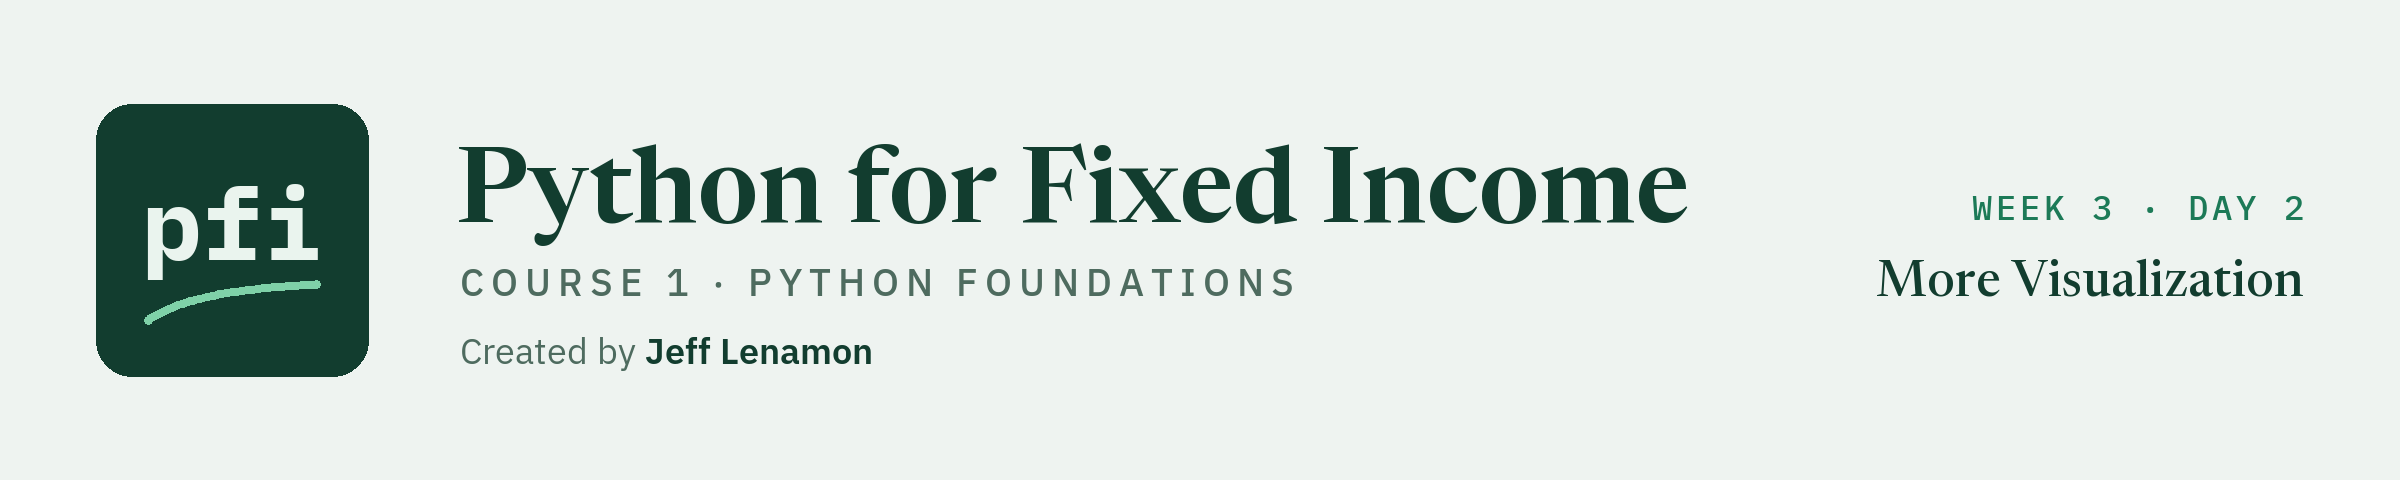

# More Visualization

Week 3. Lines fitted through a scatter, charts that show every bond, charts that answer to the mouse, and how to finish a chart so it can leave the desk.

> This course is educational content created in a personal capacity. Nothing here is investment advice or a recommendation to buy or sell any security. All portfolio data is synthetic.

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/lenamonj/python-fixed-income/blob/main/course1_python_foundations/week3/day2/12_visualization_more.ipynb)

Yesterday the desk drew seven kinds of chart from the book: histogram, box plot, bar chart, line plot, scatter plot, pair plot, and heatmap. Each one started with `fig, ax = plt.subplots()`, drew on `ax`, and carried a title and axis labels with units. Two numbers from those charts come back today: the median OAS of the book, 135.5 basis points, and the correlation of duration and OAS, -0.11.

The portfolio manager liked the pictures and has three more requests. Put a line through the scatter plots and say what its slope is. Show the individual bonds behind the boxes and the bars. And make the charts fit for a meeting: the desk's colours, readable axes, a note on the bond everyone will ask about, and a file that can go into a slide.

This notebook uses the same table as yesterday, the 200-bond holdings file joined to the rating scale, with matplotlib and seaborn, and adds one new library, **plotly**, for charts that respond to the mouse. The issuers are invented.

Every chart here describes the data. A line fitted through this file is a summary of this file. It is not a forecast, and nothing here says a bond or a sector is good or bad.

## 12.1 Setting Up

Q. Import the libraries and check which versions are running.

In [1]:
# os is used to find the data folder and, later, to check and delete a saved file
import os

import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import plotly
import plotly.express as px
import plotly.graph_objects as go
import seaborn as sns

print('pandas version:', pd.__version__)
print('numpy version:', np.__version__)
print('matplotlib version:', matplotlib.__version__)
print('seaborn version:', sns.__version__)
print('plotly version:', plotly.__version__)

pandas version: 3.0.6
numpy version: 2.5.3
matplotlib version: 3.11.2
seaborn version: 0.13.2
plotly version: 7.1.0


* `px` is the name everyone uses for `plotly.express`, the part of plotly that draws a chart from a table in one line. `go` is `plotly.graph_objects`, the part underneath it, needed once today for a surface. NumPy is back from week 2, for fitting a line.
* plotly was added to `requirements.txt` for this notebook. If the import fails with `ModuleNotFoundError`, activate the environment in PowerShell and run `python -m pip install -r requirements.txt` again. In Google Colab plotly is already installed.
* This notebook was saved with the versions printed above. Yours may differ, and in Google Colab they may be older.

Q. Load the holdings and the rating scale.

In [2]:
# on your own machine the files are in the repo's data folder. In Colab they are read from GitHub.
if os.path.exists('../../../data/holdings.csv'):
    data_folder = '../../../data/'
else:
    data_folder = 'https://raw.githubusercontent.com/lenamonj/python-fixed-income/main/data/'

holdings = pd.read_csv(data_folder + 'holdings.csv')
ratings = pd.read_csv(data_folder + 'ratings.csv')

print('holdings:', holdings.shape)
print('ratings:', ratings.shape)

holdings: (200, 19)
ratings: (18, 4)


* 200 bonds with 19 columns, and the 18 rows of the rating scale. The same two files as yesterday.

Q. Join the rating scale to the holdings and check that no row was lost or added.

In [3]:
# a left merge keeps every bond and looks up its score, bucket, and grade
book = pd.merge(holdings, ratings, on='rating', how='left')

print('Rows before:', holdings.shape[0], ' after:', book.shape[0])
print('Columns:', book.shape[1])
print('Bonds with no bucket:', book['bucket'].isna().sum())

Rows before: 200  after: 200
Columns: 22
Bonds with no bucket: 0


* 200 rows before and after, 22 columns, and no bond without a bucket. `book` is the one table every chart in this notebook is drawn from.

Q. Put the seven rating buckets in credit order.

In [4]:
# sort the scale by score, then keep each bucket name the first time it appears
bucket_order = ratings.sort_values('score')['bucket'].unique().tolist()
print(bucket_order)

['AAA', 'AA', 'A', 'BBB', 'BB', 'B', 'CCC']


* AAA first and CCC last, taken from the `score` column of the rating scale, as yesterday.

Q. Which numbers from yesterday will today's charts be checked against?

In [5]:
print('Median OAS:', book['oas'].median())
print('Mean OAS:', book['oas'].mean())
print('Correlation of duration and OAS:', round(book['duration'].corr(book['oas']), 2))
print('Correlation of coupon and yield:', round(book['coupon'].corr(book['yield_pct']), 2))
print(book['grade'].value_counts())

Median OAS: 135.5
Mean OAS: 185.75
Correlation of duration and OAS: -0.11
Correlation of coupon and yield: 0.74
grade
Investment Grade    128
High Yield           72
Name: count, dtype: int64


* A median OAS of 135.5 basis points against a mean of 185.75. A correlation of -0.11 between duration and OAS, and of 0.74 between coupon and yield. 128 Investment Grade bonds and 72 High Yield bonds.
* Units are as before: `coupon` and `yield_pct` in percent, `oas` in basis points, `duration` in years, `market_value` in dollars.

## 12.2 Regression Plot

A scatter plot shows whether two columns move together, and a correlation puts one number on it. Neither says how much one column changes when the other does. A **regression line** does. It is the straight line that passes closest to the points:

`y = intercept + slope * x`

* The **slope** is how much y changes for each extra unit of x. Its unit is the unit of y per unit of x.
* The **intercept** is the value of the line where x is zero.
* Closest has a precise meaning. For each bond, take the vertical distance between the point and the line, and square it. The regression line is the one line for which those squares add up to the smallest total. The method is called least squares.

Yesterday's heatmap gave coupon and yield a correlation of 0.74.

Q. Which straight line fits the yield best, given the coupon?

In [6]:
# np.polyfit() fits a line: the x column, the y column, then 1 for a straight line
# it returns the slope first and the intercept second
slope, intercept = np.polyfit(book['coupon'], book['yield_pct'], 1)

print('Slope:', round(slope, 2), 'percent of yield per 1 percent of coupon')
print('Intercept:', round(intercept, 2), 'percent of yield')
print('Lowest coupon:', book['coupon'].min(), ' Highest coupon:', book['coupon'].max())

Slope: 0.88 percent of yield per 1 percent of coupon
Intercept: 0.85 percent of yield
Lowest coupon: 3.25  Highest coupon: 11.0


* The slope is 0.88. Across this file, a bond with a coupon 1 percentage point higher has, on the line, a yield 0.88 percentage points higher.
* The intercept is 0.85 percent, the height of the line at a coupon of zero. No bond in the file is near there: the lowest coupon is 3.25 percent. The intercept fixes where the line sits. It is not the yield of any bond.
* `np.polyfit()` returns two values, and `slope, intercept =` stores them under two names, the same pattern as `fig, ax = plt.subplots()`.

The `1` at the end is the degree of the fit: 1 for a straight line. What happens when it is left out?

In [7]:
# the degree is missing
slope, intercept = np.polyfit(book['coupon'], book['yield_pct'])

TypeError: polyfit() missing 1 required positional argument: 'deg'

* A `TypeError`, and the last line names the problem: `polyfit() missing 1 required positional argument: 'deg'`. The function needs three things and was given two. `deg` is the degree.
* NumPy will not guess the degree. The fix is to pass it: `np.polyfit(book['coupon'], book['yield_pct'], 1)`, as in the cell before this one.
* `slope` and `intercept` still hold the values from that earlier cell. The failed line never got as far as storing anything.

Q. What yield does the line give at a coupon of 5 percent, and at 8 percent?

In [8]:
# the line is intercept + slope * x
print('At a 5 percent coupon:', round(intercept + slope * 5, 2), 'percent')
print('At an 8 percent coupon:', round(intercept + slope * 8, 2), 'percent')

At a 5 percent coupon: 5.26 percent
At an 8 percent coupon: 7.91 percent


* 5.26 percent and 7.91 percent. The two differ by 3 times the slope.
* These are points on the line. They are not the yield of any bond, and not a yield any bond should have.

Q. Draw the 200 bonds and the line through them.

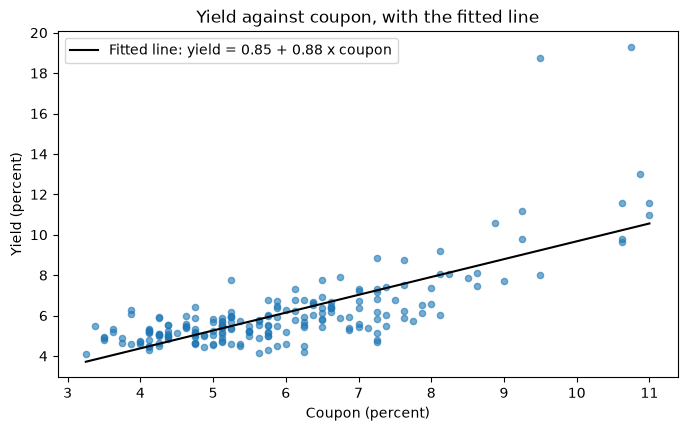

In [9]:
fig, ax = plt.subplots(figsize=(8, 4.5))

# the bonds. s= is the size of each point, and alpha= makes the points see-through.
ax.scatter(book['coupon'], book['yield_pct'], s=20, alpha=0.6)

# a straight line needs two points: the lowest and the highest coupon in the file
line_x = np.array([book['coupon'].min(), book['coupon'].max()])
line_y = intercept + slope * line_x
ax.plot(line_x, line_y, color='black', label='Fitted line: yield = 0.85 + 0.88 x coupon')

ax.legend()
ax.set_title('Yield against coupon, with the fitted line')
ax.set_xlabel('Coupon (percent)')
ax.set_ylabel('Yield (percent)')

plt.show()

* The line runs from the lowest coupon, 3.25 percent, to the highest, 11 percent, rising 0.88 for each point of coupon.
* The points scatter on both sides of it. Two bonds near the top of the chart, with yields above 18 percent, are far above the line. Least squares gives a distant point a large say, because its distance is squared.
* `line_x` is an array of two numbers, and `intercept + slope * line_x` works out both heights at once, as arrays did in week 2.

seaborn does the fit and the drawing in one call.

Q. Draw the same chart with seaborn.

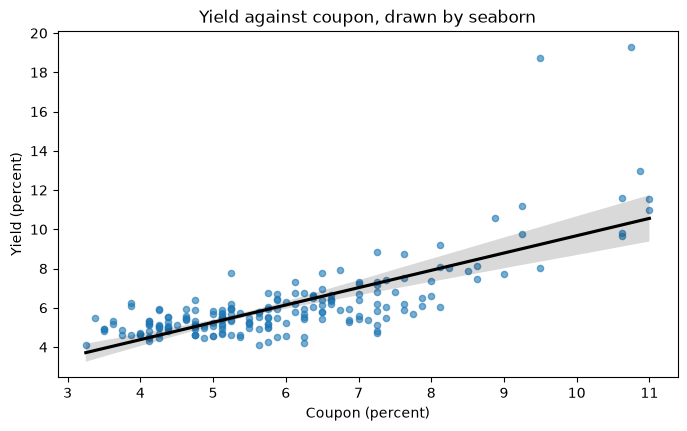

In [10]:
fig, ax = plt.subplots(figsize=(8, 4.5))

# regplot() draws the points, fits the line, and shades a band around it
# seed= fixes the random draws behind the band, so the chart is the same on every run
sns.regplot(data=book, x='coupon', y='yield_pct', seed=0,
            scatter_kws={'s': 20, 'alpha': 0.6}, line_kws={'color': 'black'}, ax=ax)

ax.set_title('Yield against coupon, drawn by seaborn')
ax.set_xlabel('Coupon (percent)')
ax.set_ylabel('Yield (percent)')

plt.show()

* The same points and the same line: slope 0.88, intercept 0.85. seaborn draws the line and does not print its numbers, which is why the cell with `np.polyfit()` came first.
* The shaded band is new. It shows how firmly this file pins the line down. seaborn builds 1,000 new files of 200 bonds by picking bonds at random from this one, with repeats allowed, fits a line to each, and shades the range that holds the middle 95 percent of those lines. It is called a 95 percent confidence band.
* The band is narrow in the middle, where most of the bonds are, and wider at the high-coupon end, where there are few bonds and the two high-yield points pull on the line.
* The band is about the line and not about the bonds. Most of the 200 points lie outside it, and that is normal.
* `scatter_kws` and `line_kws` are dictionaries of settings that seaborn passes on to the points and to the line.

Q. How much of the variation in yield does the line account for?

In [11]:
# the correlation, and its square
r = book['coupon'].corr(book['yield_pct'])

print('Correlation:', round(r, 2))
print('R squared:', round(r ** 2, 2))

Correlation: 0.74
R squared: 0.55


* The correlation is 0.74 and its square is 0.55. **R squared** is the share of the variation in y that a straight line on x accounts for: here 55 percent of the variation in yield across the file. The other 45 percent is the scatter around the line.
* R squared runs from 0 to 1. At 1 every point is on the line.

**Excel side by side.** On a Scatter chart in Excel, the line is a trendline: select the chart, then Chart Elements, Trendline, More Options, and choose Linear. Two checkboxes in the same pane, Display Equation on chart and Display R-squared value on chart, write the numbers beside the line. The worksheet functions give the same numbers in cells:

| Job | Python | Excel | Result |
| --- | --- | --- | --- |
| Slope | `np.polyfit(x, y, 1)[0]` | `=SLOPE(L2:L201, G2:G201)` | 0.88 |
| Intercept | `np.polyfit(x, y, 1)[1]` | `=INTERCEPT(L2:L201, G2:G201)` | 0.85 |
| R squared | `x.corr(y) ** 2` | `=RSQ(L2:L201, G2:G201)` | 0.55 |
| The line at a coupon of 5 | `intercept + slope * 5` | `=INTERCEPT(L2:L201, G2:G201) + SLOPE(L2:L201, G2:G201) * 5` | 5.26 |
| The line on the chart | `sns.regplot(...)` | Chart Elements, Trendline, Linear | |

The formulas assume the coupon in column G and the yield in column L, where they are when the holdings file is opened in Excel. Mind the order of the arguments. The three Excel functions take the y range first and the x range second. `np.polyfit()` takes x first and y second. The shaded band is seaborn's addition. The Trendline pane has no option for it.

**Predict 1**

Yesterday's scatter plot of OAS against duration was a cloud, with a correlation of -0.11.

```
slope, intercept = np.polyfit(book['duration'], book['oas'], 1)
```

What will the slope be?

> A) Positive. Longer bonds carry more spread.
>
> B) Negative, and small next to the range of the OAS.
>
> C) Exactly zero, because the correlation is close to zero.

Decide, then run the cell.

Slope: -6.15 basis points per year of duration
Intercept: 225.52 basis points
R squared: 0.01


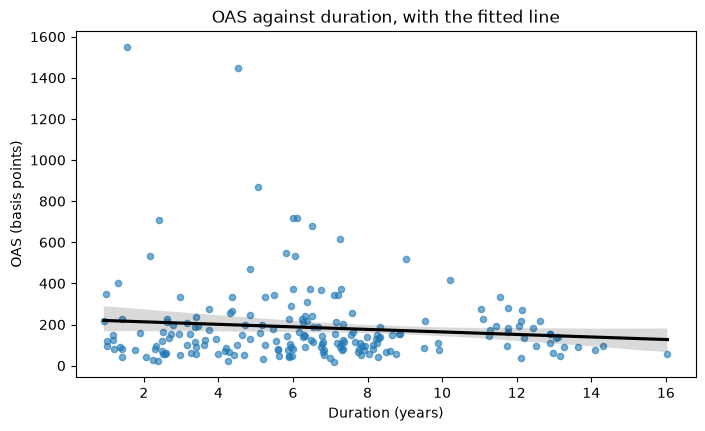

In [12]:
# OAS on duration: the slope is in basis points per year
duration_slope, duration_intercept = np.polyfit(book['duration'], book['oas'], 1)

print('Slope:', round(duration_slope, 2), 'basis points per year of duration')
print('Intercept:', round(duration_intercept, 2), 'basis points')
print('R squared:', round(book['duration'].corr(book['oas']) ** 2, 2))

fig, ax = plt.subplots(figsize=(8, 4.5))
sns.regplot(data=book, x='duration', y='oas', seed=0,
            scatter_kws={'s': 20, 'alpha': 0.6}, line_kws={'color': 'black'}, ax=ax)

ax.set_title('OAS against duration, with the fitted line')
ax.set_xlabel('Duration (years)')
ax.set_ylabel('OAS (basis points)')

plt.show()

* The answer is B. The slope is -6.15 basis points per year of duration, and the intercept is 225.52 basis points. The slope of a fitted line always has the same sign as the correlation.
* The line is nearly flat against an OAS column that runs from 19 to 1,551. R squared is 0.01: the line accounts for about 1 percent of the variation in OAS. A line can always be fitted. Whether it says much is a separate question, and R squared answers it.
* The band is wide next to the tilt of the line. Lines with quite different slopes fit this cloud about as well.

Yesterday the colours split this cloud into two layers, one for each grade.

Q. Fit and draw one line for each grade.

Investment Grade - slope: 2.99 bp per year, intercept: 78.79 bp
   correlation: 0.24
High Yield - slope: -7.86 bp per year, intercept: 384.51 bp
   correlation: -0.1


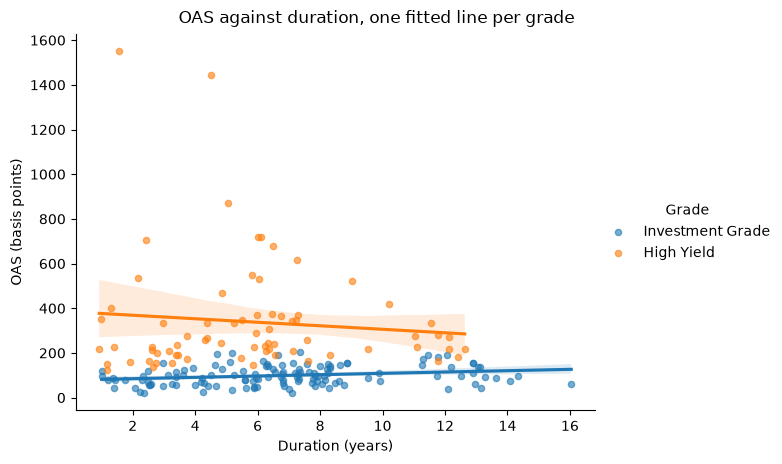

In [13]:
# the slope and intercept of each grade, fitted on that grade's bonds only
for grade in ['Investment Grade', 'High Yield']:
    part = book[book['grade'] == grade]
    grade_slope, grade_intercept = np.polyfit(part['duration'], part['oas'], 1)
    print(grade, '- slope:', round(grade_slope, 2), 'bp per year, intercept:', round(grade_intercept, 2), 'bp')
    print('   correlation:', round(part['duration'].corr(part['oas']), 2))

# lmplot() is regplot() with hue=. It makes its own figure, as pairplot() did.
# height= is the height in inches, and aspect= is the width divided by the height
grid = sns.lmplot(data=book, x='duration', y='oas', hue='grade', seed=0,
                  height=4.5, aspect=1.4, scatter_kws={'s': 20, 'alpha': 0.6})

grid.set_axis_labels('Duration (years)', 'OAS (basis points)')
grid.legend.set_title('Grade')
grid.figure.suptitle('OAS against duration, one fitted line per grade', y=1.02)

plt.show()

* Two lines with opposite tilts. Across the 128 Investment Grade bonds the slope is 2.99 basis points per year of duration, from an intercept of 78.79. Across the 72 High Yield bonds it is -7.86 basis points per year, from an intercept of 384.51.
* The signs match the correlations within each grade, 0.24 and -0.1, the same two figures as yesterday. The line for the whole book, at -6.15, described neither group.
* The High Yield band is much wider than the Investment Grade band. There are fewer High Yield bonds and their OAS values are far more scattered, so the file pins that line down less firmly.
* `lmplot()` builds the whole figure and returns a grid, so there is no `fig, ax` line. The axis labels are set on the grid, and the title on `grid.figure`.
* These lines describe an invented file on one date. They do not say what the spread of any bond should be or will be.

## 12.3 Joint Plot

A scatter plot shows two columns together and hides how each one is distributed on its own. A histogram shows one column and hides the other. A **joint plot** puts all three on one figure: the scatter in the middle, the histogram of the x column along the top, and the histogram of the y column down the right side.

Q. Show OAS against duration, with the distribution of each.

Bonds with an OAS below 250 bp: 164
Bonds with a duration of 10 years or less: 169


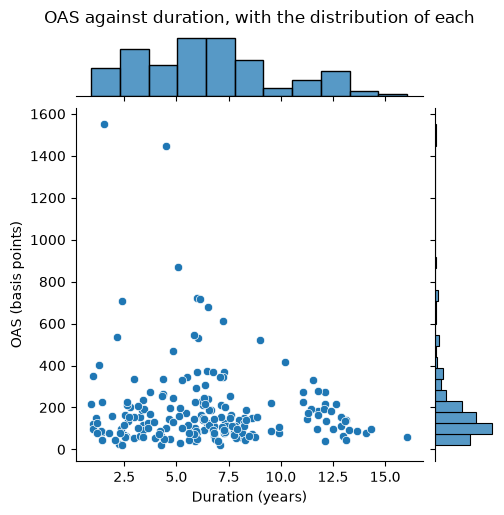

In [14]:
# two counts to check the side charts against
print('Bonds with an OAS below 250 bp:', (book['oas'] < 250).sum())
print('Bonds with a duration of 10 years or less:', (book['duration'] <= 10).sum())

# jointplot() makes its own figure, a square one. height= is its size in inches.
grid = sns.jointplot(data=book, x='duration', y='oas', height=5)

grid.set_axis_labels('Duration (years)', 'OAS (basis points)')
grid.figure.suptitle('OAS against duration, with the distribution of each', y=1.02)

plt.show()

* The middle panel is yesterday's cloud. The histogram along the top belongs to the x axis: duration. 169 of the 200 bonds have a duration of 10 years or less, and the bars thin out from there to 16.
* The histogram down the right belongs to the y axis and is the OAS histogram of yesterday turned on its side: 164 of the 200 bonds below 250 basis points, and a long thin tail upward.
* Read together, they explain the scatter. The points are dense along the bottom because that is where the OAS column is dense, at every duration.

Q. Draw it again with the two grades in different colours.

                  oas              duration                
                  min median   max      min  median     max
grade                                                      
High Yield        125  250.5  1551    0.927  5.8725  12.631
Investment Grade   19   95.0   204    1.005  6.7945  16.042


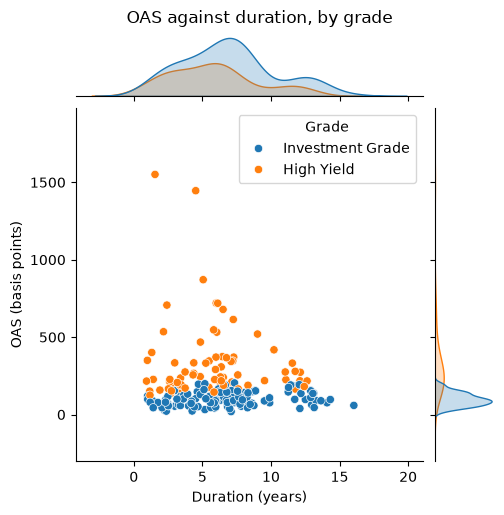

In [15]:
# the range of each column within each grade
print(book.groupby('grade')[['oas', 'duration']].agg(['min', 'median', 'max']))

# hue= colours the points by grade, and the side charts become one smooth curve per grade
grid = sns.jointplot(data=book, x='duration', y='oas', hue='grade', height=5)

grid.set_axis_labels('Duration (years)', 'OAS (basis points)')
grid.ax_joint.legend(title='Grade')
grid.figure.suptitle('OAS against duration, by grade', y=1.02)

plt.show()

* With `hue=`, the side charts change from bars to **density curves**: a smoothed outline of a histogram, one per grade. The height of the curve shows where the values are concentrated.
* On the right, the Investment Grade curve is a tall narrow peak: every one of those bonds has an OAS between 19 and 204 basis points. The High Yield curve is low and long, from 125 up to 1,551.
* Along the top the two curves overlap for most of their length. The median duration is 6.79 years for Investment Grade and 5.87 for High Yield. The grades differ far more in spread than in duration.
* The smooth curves run a little past the data at both ends, and the axes have stretched to fit them. Section 12.4 comes back to that.
* The grid has three axes: `grid.ax_joint` in the middle, and `grid.ax_marg_x` and `grid.ax_marg_y` for the sides. The legend is on the middle one.
* `kind='reg'` in place of `hue=` adds the fitted line of section 12.2 to the middle panel.

**Excel side by side.** Excel has no single chart for this. The same picture is three charts arranged on a sheet: a Scatter chart, with a Histogram of the duration column above it and a Histogram of the OAS column beside it. The counts behind the two side charts are `=COUNTIF(M2:M201, "<250")`, which returns 164, and `=COUNTIF(N2:N201, "<=10")`, which returns 169, with the OAS in column M and the duration in column N.

## 12.4 Violin, Strip, and Swarm Plots

Yesterday's box plot compared groups with five numbers each. It did not show the shape of the distribution inside a box, or how many bonds a box was drawn from. Three charts fill that gap.

A **violin plot** is a box plot with a density curve wrapped around it. The curve is drawn twice, mirrored, so the shape is wide where the bonds are concentrated and thin where they are few.

Q. How is duration distributed within each grade?

                  count  mean   std   min   25%   50%   75%    max
grade                                                             
High Yield         72.0  5.74  3.15  0.93  3.23  5.87  7.16  12.63
Investment Grade  128.0  6.88  3.40  1.00  4.38  6.79  8.30  16.04


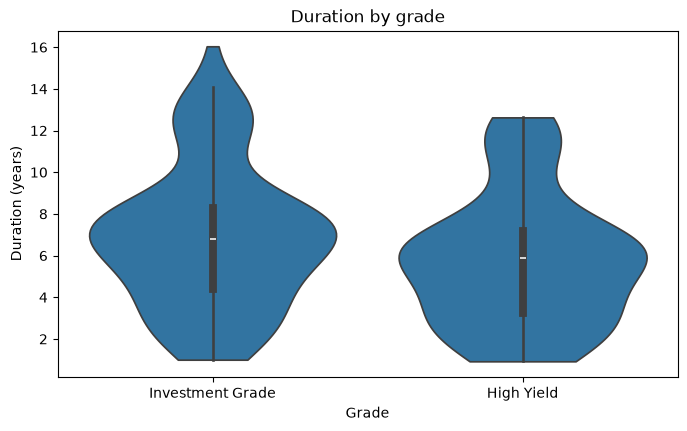

In [16]:
# the numbers behind the two shapes
print(book.groupby('grade')['duration'].describe().round(2))

fig, ax = plt.subplots(figsize=(8, 4.5))

# one violin for each value of x. cut=0 ends each shape at its lowest and its highest bond.
sns.violinplot(data=book, x='grade', y='duration', cut=0, ax=ax)

ax.set_title('Duration by grade')
ax.set_xlabel('Grade')
ax.set_ylabel('Duration (years)')

plt.show()

* Inside each violin is a small box plot: a thick bar from the first quartile to the third, a thin line for the whiskers, and a white mark at the median. The medians are 6.79 years for Investment Grade and 5.87 for High Yield.
* The outline is the new information. Both shapes are widest between about 5 and 8 years, with a second, smaller bulge near 12 years. The Investment Grade shape carries on up to its longest bond at 16.04 years. The High Yield shape stops at 12.63.
* `cut=0` is the reason each shape ends at its lowest and highest bond. The next question shows what seaborn draws without it.
* The width shows where the bonds are concentrated. It is not a count: the two violins are drawn equally wide at their widest, though one holds 128 bonds and the other 72.

**Predict 2**

The lowest OAS among the Investment Grade bonds is 19 basis points. No bond in the file has a negative OAS.

```
sns.violinplot(data=book, x='grade', y='oas', ax=ax)
```

This call has no `cut=0`. Where does the bottom of the Investment Grade violin end?

> A) At 19 basis points, the lowest value.
>
> B) At 0.
>
> C) Below 0.

Decide, then run the cell.

Lowest OAS in each grade:
grade
High Yield          125
Investment Grade     19
Name: oas, dtype: int64


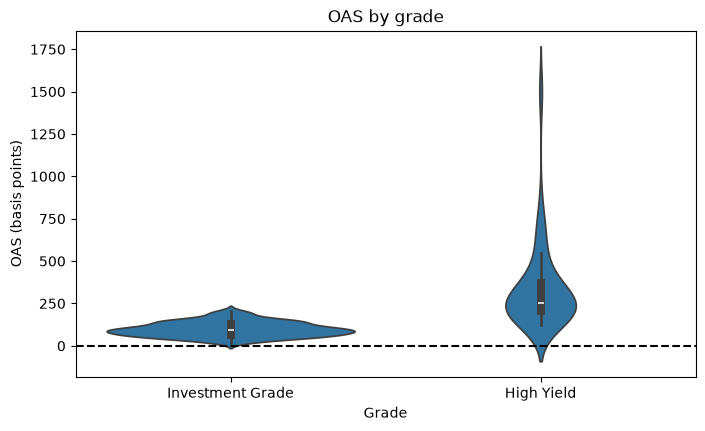

In [17]:
print('Lowest OAS in each grade:')
print(book.groupby('grade')['oas'].min())

fig, ax = plt.subplots(figsize=(8, 4.5))

# no cut=0 this time
sns.violinplot(data=book, x='grade', y='oas', ax=ax)

# a horizontal line at zero, to see where the shapes end
ax.axhline(0, color='black', linestyle='--')

ax.set_title('OAS by grade')
ax.set_xlabel('Grade')
ax.set_ylabel('OAS (basis points)')

plt.show()

* The answer is C. Both shapes cross the dashed line at zero, although the lowest OAS in the file is 19 basis points and the lowest High Yield OAS is 125.
* The outline is a smoothed curve, and the smoothing spreads a little of each bond to both sides of its value. By default seaborn lets the curve run on past the lowest and the highest bond until it fades out. The part below 19 is drawing, not data.
* A reader who does not know this can take the tail of a violin for bonds that are not there. Check the ends of a violin against `min()` and `max()`.

Q. Put `cut=0` back, and stop each shape at its lowest and highest bond.

Highest OAS in each grade:
grade
High Yield          1551
Investment Grade     204
Name: oas, dtype: int64


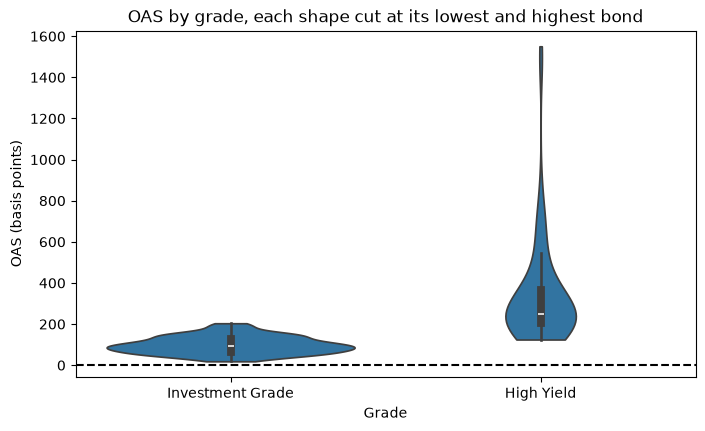

In [18]:
print('Highest OAS in each grade:')
print(book.groupby('grade')['oas'].max())

fig, ax = plt.subplots(figsize=(8, 4.5))

# cut=0 ends each violin at the lowest and the highest value in its group
sns.violinplot(data=book, x='grade', y='oas', cut=0, ax=ax)

ax.axhline(0, color='black', linestyle='--')

ax.set_title('OAS by grade, each shape cut at its lowest and highest bond')
ax.set_xlabel('Grade')
ax.set_ylabel('OAS (basis points)')

plt.show()

* Both shapes now stay above the zero line. The Investment Grade violin runs from 19 to 204 basis points and the High Yield violin from 125 to 1,551, the ranges in the table.
* The Investment Grade violin is short and wide, and the High Yield violin is drawn out into a long thin neck by its few very wide bonds. The same contrast as the two boxes of yesterday, with the shape added.

A violin still summarizes. A **strip plot** draws every bond as its own point, in a column for each category.

Q. Draw every bond's OAS, in a column for each rating bucket.

bucket
AAA     2
AA      8
A      56
BBB    62
BB     49
B      18
CCC     5
Name: count, dtype: int64


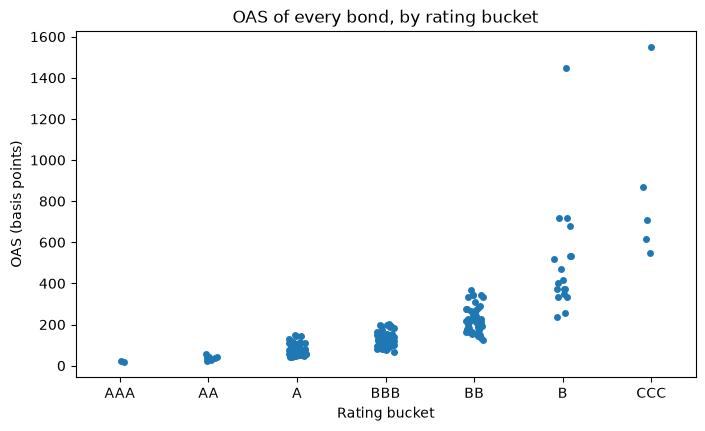

In [19]:
# how many points to expect in each column
print(book['bucket'].value_counts().loc[bucket_order])

# the points are nudged sideways at random so they do not sit on top of each other
# fixing NumPy's random seed makes the nudges the same on every run
np.random.seed(0)

fig, ax = plt.subplots(figsize=(8, 4.5))

# stripplot() draws one point per bond. order= puts the buckets in credit order.
sns.stripplot(data=book, x='bucket', y='oas', order=bucket_order, ax=ax)

ax.set_title('OAS of every bond, by rating bucket')
ax.set_xlabel('Rating bucket')
ax.set_ylabel('OAS (basis points)')

plt.show()

* 200 points, one for each bond. The counts are visible without a table: 2 points in the AAA column and 5 in the CCC column, against 56, 62, and 49 in the three crowded columns in the middle.
* Yesterday's box plot of the same data drew the AAA box and the BBB box with the same outline. Here nobody can mistake a column of 2 bonds for a column of 62.
* The two widest bonds, at 1,446 in the B column and 1,551 in the CCC column, are single points far above the rest.
* The sideways position of a point within its column is random and carries no meaning. It is called **jitter**. Only the height is data.

A **swarm plot** also draws every bond, and places the points side by side so that none overlap.

Q. Draw every bond's duration, in a column for each grade.

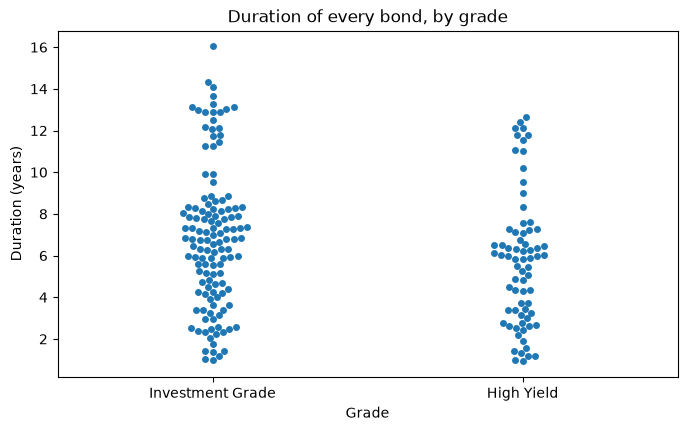

In [20]:
fig, ax = plt.subplots(figsize=(8, 4.5))

# swarmplot() moves each point sideways just far enough to clear its neighbours
sns.swarmplot(data=book, x='grade', y='duration', ax=ax)

ax.set_title('Duration of every bond, by grade')
ax.set_xlabel('Grade')
ax.set_ylabel('Duration (years)')

plt.show()

* 128 points on the left and 72 on the right. The width of the swarm at any height shows how many bonds have about that duration, so the swarm has the outline of the violin and is made of the bonds themselves.
* The single point at the top of the Investment Grade swarm is the longest bond in the file, at 16.04 years.
* Nothing here is random. The sideways position is worked out from the neighbours, so the chart is the same on every run with no seed.
* A swarm needs room. With many points in a narrow column, seaborn cannot place them all and says so in a warning. The strip plot is the one to use then, which is why the seven-bucket chart above is a strip plot.

**Excel side by side.**

| Job | Python | Excel |
| --- | --- | --- |
| Shape of each group | `sns.violinplot(...)` | no violin chart type. The nearest is Box and Whisker |
| Every bond as a point | `sns.stripplot(...)`, `sns.swarmplot(...)` | on a Box and Whisker chart: Format Data Series, Show inner points |
| Lowest and highest of one group | `book.groupby('grade')['oas'].min()` | `=MINIFS(M2:M201, V2:V201, "Investment Grade")`, `=MAXIFS(M2:M201, V2:V201, "Investment Grade")` |
| Bonds in one bucket | `book['bucket'].value_counts()` | `=COUNTIF(U2:U201, "CCC")` |

The formulas assume the joined table on a sheet, with the OAS in column M, the bucket in column U, and the grade in column V. `MINIFS` and `MAXIFS` return 19 and 204, and the `COUNTIF` returns 5. `MINIFS` and `MAXIFS` are in Excel 2019 and later.

## 12.5 Catplot

The violin, strip, and swarm plots all show a number split by a category. seaborn has one function that reaches all of them: `catplot()`, for categorical plot. Its `kind=` argument picks the chart, and its `col=` argument splits the figure into panels, one for each value of another column.

Q. Draw every bond's duration by sector, with one panel for each grade.

grade           High Yield  Investment Grade
sector                                      
Consumer                 9                17
Energy                   3                14
Financials               6                20
Health Care              6                14
Industrials              8                12
Materials               13                13
Technology               5                 7
Telecom                 13                 8
Transportation           7                13
Utilities                2                10
Longest bond: Transportation - Investment Grade - 16.042 years


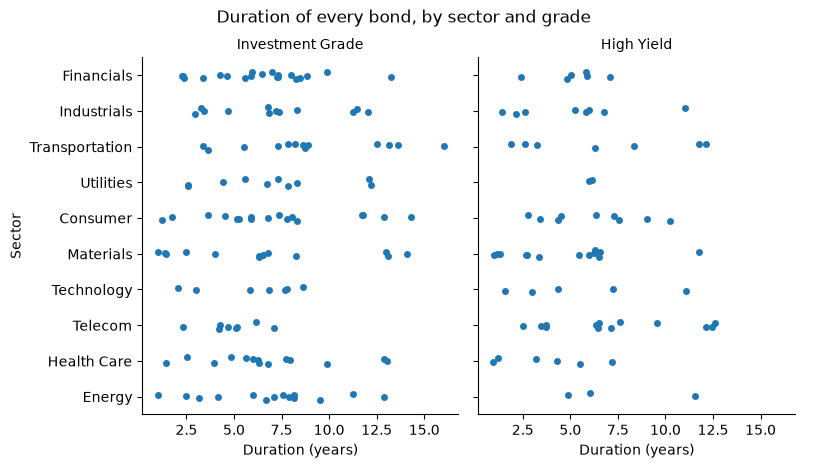

In [21]:
# how many points to expect in each row of each panel
print(pd.crosstab(book['sector'], book['grade']))

# the longest bond in the file. idxmax() gives the row label of the largest value.
longest = book.loc[book['duration'].idxmax()]
print('Longest bond:', longest['sector'], '-', longest['grade'], '-', longest['duration'], 'years')

# a strip plot has random jitter, so fix the seed
np.random.seed(0)

# kind= picks the chart, and col= makes one panel for each grade
# the sector is on the y axis, so the long names are written across the page
grid = sns.catplot(data=book, x='duration', y='sector', col='grade', kind='strip',
                   height=4.5, aspect=0.9)

grid.set_axis_labels('Duration (years)', 'Sector')
grid.set_titles('{col_name}')
grid.figure.suptitle('Duration of every bond, by sector and grade', y=1.03)

plt.show()

* Two panels with the same ten sectors down the side and the same duration axis along the bottom, so a row can be read straight across from one grade to the other.
* The counts in the table are the points in each row. Utilities has 10 Investment Grade points and 2 High Yield points. Materials has 13 in each panel. Telecom is the one sector with more High Yield bonds than Investment Grade bonds, 13 against 8.
* The point furthest to the right is in the Transportation row of the Investment Grade panel: the longest bond in the file, at 16.042 years.
* `pd.crosstab()` counts the rows for each pair of values in two columns. It is a pivot table of counts in one short call.
* Like `pairplot()`, `lmplot()`, and `jointplot()`, `catplot()` builds its own figure and returns a grid. Changing `kind='strip'` to `'swarm'`, `'violin'`, `'bar'`, or `'point'` redraws the same split as a different chart.

**Excel side by side.** Excel draws one chart from one range, so a panel per group is one chart per group: filter the table to Investment Grade, build the chart, then do the same for High Yield and set the two side by side. The table of counts is a pivot table with `sector` in Rows, `grade` in Columns, and Count of `cusip` in Values, or one formula per cell: `=COUNTIFS(E2:E201, "Utilities", V2:V201, "High Yield")` returns 2, with the sector in column E and the grade in column V.

## 12.6 Interactive Charts with plotly

Every chart so far is a fixed picture. To find out which bond a point is, the desk would go back to the table. An **interactive chart** answers on the spot: rest the pointer on a point and a box shows its values, drag across an area to zoom in, double-click to zoom back out, and click a name in the legend to hide that group.

plotly draws such charts. `plotly.express`, imported as `px`, works like seaborn: pass the table, and name the columns as text.

The interactive charts appear when you run the cells. GitHub's preview of this notebook may show nothing in their place.

Q. Draw OAS against duration, so that pointing at a bond shows which one it is.

In [22]:
# the widest bond in the file, to find on the chart
widest = book.loc[book['oas'].idxmax()]
print(widest[['ticker', 'issuer', 'sector', 'rating', 'duration', 'oas']])

# color= is plotly's hue=. hover_name= is the heading of the box that appears at a point,
# and hover_data= lists extra columns to show in it. labels= replaces column names with words.
fig = px.scatter(book, x='duration', y='oas', color='grade',
                 hover_name='issuer', hover_data=['ticker', 'sector', 'rating'],
                 labels={'duration': 'Duration (years)', 'oas': 'OAS (basis points)', 'grade': 'Grade',
                         'ticker': 'Ticker', 'sector': 'Sector', 'rating': 'Rating'},
                 title='OAS against duration, one point per bond',
                 width=800, height=450)

# show() displays a plotly figure
fig.show()

ticker                  FESR
issuer      Feskovar Devices
sector            Technology
rating                  CCC+
duration               1.546
oas                     1551
Name: 65, dtype: object


* The same cloud as section 12.2, in plotly's colours, with a toolbar that appears at the top right of the chart.
* Point at the highest point on the chart. The box is headed Feskovar Devices and reads FESR, Technology, CCC+, with a duration of 1.546 years and an OAS of 1,551 basis points: the row printed above the chart. It is a row of an invented file, and the issuer does not exist.
* Drag a rectangle around the crowded lower part of the chart to zoom in on it. Double-click to return. Click High Yield in the legend to hide those points, and click again to bring them back.
* A plotly figure is not a matplotlib figure. There is no `ax`, and the title and labels are arguments of the one call. The figure is displayed with `fig.show()`, not `plt.show()`.
* Width and height are in pixels here, not inches.

Q. How much market value is in each sector, split by grade? Draw it so that each piece can be read by pointing at it.

In [23]:
# market value in millions of dollars for each pair of sector and grade
# a list of two columns in groupby() makes one group per pair, and reset_index() turns the result into a table
value_table = (book.groupby(['sector', 'grade'])['market_value'].sum() / 1_000_000).round(2).reset_index()
print(value_table.head(4))

# the sectors from largest to smallest total, for the order of the bars
sector_totals = value_table.groupby('sector')['market_value'].sum().sort_values(ascending=False)
print(sector_totals.round(2).head(3))

# px.bar() stacks the rows that share a sector. category_orders= sets the order along the axis.
fig = px.bar(value_table, x='sector', y='market_value', color='grade',
             category_orders={'sector': sector_totals.index.tolist()},
             labels={'sector': 'Sector', 'market_value': 'Market value (millions of dollars)', 'grade': 'Grade'},
             title='Market value by sector and grade',
             width=800, height=450)

fig.show()

     sector             grade  market_value
0  Consumer        High Yield         19.02
1  Consumer  Investment Grade         37.61
2    Energy        High Yield          7.35
3    Energy  Investment Grade         31.48
sector
Materials     71.70
Financials    68.22
Consumer      56.63
Name: market_value, dtype: float64


* Ten bars, each in two pieces, tallest on the left. Materials is the tallest at 71.70 million dollars and Financials is next at 68.22 million, the same totals as yesterday's bar chart.
* Point at a piece to read its value. The first rows of the table are the two pieces of the Consumer bar: 19.02 million dollars of High Yield and 37.61 million of Investment Grade.
* Click Investment Grade in the legend and the bars drop to their High Yield pieces alone, redrawn from zero. That comparison would take a second chart in matplotlib.
* Two things are new in the first line. `groupby()` was given a list of two columns, so it made one group for each pair of sector and grade. `reset_index()` then moved the sector and the grade out of the row labels and into ordinary columns, which is the shape plotly wants: one row per piece of a bar.

An interactive chart can be saved as a web page and opened in any browser, with the hover boxes still working.

Q. Save the chart as a file, check that it is there, then tidy up.

In [24]:
# write_html() saves the figure as a web page in the working folder
# include_plotlyjs='cdn' keeps the file small: the browser fetches plotly's own code from the internet
fig.write_html('market_value_by_sector.html', include_plotlyjs='cdn')

print('File exists:', os.path.exists('market_value_by_sector.html'))
print('Size in bytes:', os.path.getsize('market_value_by_sector.html'))

# os.remove() deletes the file, so the folder is left as it was found
os.remove('market_value_by_sector.html')
print('File exists after removing it:', os.path.exists('market_value_by_sector.html'))

File exists: True
Size in bytes: 9285
File exists after removing it: False


* The file was written, it is under 10,000 bytes, and it is gone again. Anyone sent that file could open it in a browser and point at the bars, with no Python installed.
* Without `include_plotlyjs='cdn'` the file carries a full copy of plotly's code and is several megabytes.
* The file contains the data behind the chart, every number in `value_table`. The rule from day 1 applies to a chart file as it does to a spreadsheet: this one is synthetic, and nothing from an employer goes into a file that leaves the building without permission.

### A third dimension

A scatter plot places a bond by two numbers. plotly can add a third axis and draw the points in a space that can be turned with the mouse.

DTS is duration times spread. In this file it was built from the `spread_duration` column and the OAS.

Q. Check that, before drawing anything.

In [25]:
# is the spread duration the same number as the duration in this file?
print('Rows where duration equals spread duration:', (book['duration'] == book['spread_duration']).sum())

# the largest gap between the dts column and spread duration times OAS
gap = (book['dts'] - book['spread_duration'] * book['oas']).abs()
print('Largest gap:', round(gap.max(), 3))

Rows where duration equals spread duration: 200
Largest gap: 0.05


* The two duration columns are equal in all 200 rows, so either can go on the chart. The largest gap between `dts` and the product is 0.05, which is rounding: the file holds DTS to one decimal place.
* So DTS is fixed by the other two columns. Given a duration and an OAS, there is one DTS.

Q. Draw the 200 bonds in three dimensions: duration, OAS, and DTS.

In [26]:
# scatter_3d() is px.scatter() with a z axis
fig = px.scatter_3d(book, x='duration', y='oas', z='dts', color='grade',
                    hover_name='issuer', hover_data=['rating'],
                    labels={'duration': 'Duration (years)', 'oas': 'OAS (basis points)', 'dts': 'DTS',
                            'grade': 'Grade', 'rating': 'Rating'},
                    title='Duration, OAS, and DTS of the 200 bonds',
                    width=800, height=550)

# smaller points, so that 200 of them can be told apart
fig.update_traces(marker={'size': 3})

fig.show()

* Drag the chart to rotate it. Turn it until you look along the sheet, and the 200 points line up on a curved surface, low along both axes and rising toward the corner where duration and OAS are both large.
* The points do not fill the space. They cannot: the check above showed that DTS is duration times OAS to within 0.05, so each bond sits on the surface `z = x * y`. From most angles that is hard to see, and from the right angle it is obvious. That is what rotating is for.
* The scroll wheel zooms, and pointing at a bond shows the issuer name, as in the flat chart.

The interactive chart does not appear in a saved file or on a printed page. matplotlib can draw a still view of the same points.

Q. Draw a still view of the three columns with matplotlib.

Largest DTS: 6525.8


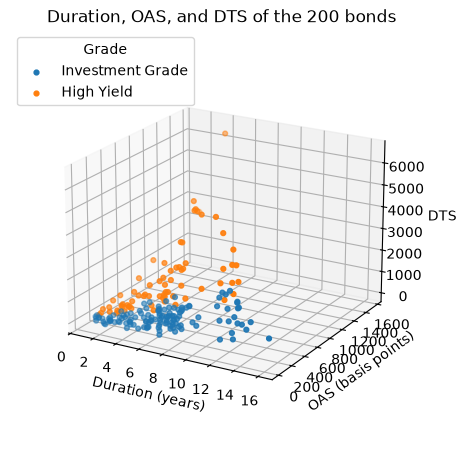

In [27]:
# subplot_kw asks for a 3D axes in place of the usual flat one
fig, ax = plt.subplots(figsize=(8, 5.5), subplot_kw={'projection': '3d'})

print('Largest DTS:', book['dts'].max())

# a 3D scatter takes three columns: x, y, and z
for grade in ['Investment Grade', 'High Yield']:
    part = book[book['grade'] == grade]
    ax.scatter(part['duration'], part['oas'], part['dts'], s=12, label=grade)

# the viewing angle: elev is the height of the eye in degrees, and azim turns the chart around
ax.view_init(elev=20, azim=-60)

# draw the box a little smaller, so that the three axis labels fit on the figure
ax.set_box_aspect(None, zoom=0.85)

ax.legend(title='Grade', loc='upper left')
ax.set_title('Duration, OAS, and DTS of the 200 bonds')
ax.set_xlabel('Duration (years)')
ax.set_ylabel('OAS (basis points)')
ax.set_zlabel('DTS', labelpad=10)

plt.show()

* The same 200 points from one fixed angle. The highest point is the bond with the largest DTS, 6,525.8.
* A 3D axes has a third label, `set_zlabel()`, and `view_init()` chooses the one angle the reader gets. A still 3D chart cannot be turned, so depth is hard to judge. It is a fallback, and the flat scatter plots of this notebook say more on paper.

A scatter draws rows of a table. A **surface** draws a formula: a height for every pair of x and y. The classic one on a bond desk is price as a function of yield and maturity.

The price of a bond on a coupon date is the present value of its coupons plus the present value of its face. For a bond paying a coupon of c percent a year in two halves, with n half-year periods left and a yield of y per half-year as a decimal:

`price = c / 2 * (1 - (1 + y) ** -n) / y + 100 * (1 + y) ** -n`

This is the convention of the holdings file: semiannual coupons, and a price per 100 of face. Course 2 covers the pricing itself. Here the formula is only the thing to draw.

Q. Write the formula as a function, and price a 5 percent bond at a few yields.

In [28]:
def bond_price(yield_pct, years, coupon=5.0):
    # the yield per half-year as a decimal, and the number of half-year periods
    y = yield_pct / 100 / 2
    n = years * 2
    # present value of the coupons, plus present value of the 100 of face
    return coupon / 2 * (1 - (1 + y) ** -n) / y + 100 * (1 + y) ** -n


print('5 percent yield, 10 years:', round(bond_price(5, 10), 2))
print('5 percent yield, 30 years:', round(bond_price(5, 30), 2))
print('10 percent yield, 30 years:', round(bond_price(10, 30), 2))
print('1 percent yield, 30 years:', round(bond_price(1, 30), 2))
print('3 percent yield, 30 years:', round(bond_price(3, 30), 2))
print('7 percent yield, 30 years:', round(bond_price(7, 30), 2))

5 percent yield, 10 years: 100.0
5 percent yield, 30 years: 100.0
10 percent yield, 30 years: 52.68
1 percent yield, 30 years: 203.45
3 percent yield, 30 years: 139.38
7 percent yield, 30 years: 75.06


* When the yield equals the coupon the price is 100, at 10 years and at 30.
* At a yield of 10 percent the 30-year bond is priced at 52.68, and at a yield of 1 percent at 203.45.
* The 30-year price is 139.38 at a yield of 3 percent and 75.06 at 7 percent: 39.38 above 100 for a yield 2 points below the coupon, and 24.94 below 100 for a yield 2 points above it.
* These are results of arithmetic on an imagined bond. They are not prices of anything in the market.

Q. Work out the price for every yield from 1 to 10 percent and every maturity from 1 to 30 years.

In [29]:
# the yields, half a percent apart, and the maturities, a year apart
yields = np.arange(1, 10.5, 0.5)
years = np.arange(1, 31)

# meshgrid() builds two tables of the same shape: the yield of every cell and the maturity of every cell
yield_grid, years_grid = np.meshgrid(yields, years)

# the function works on whole arrays, so one call prices every cell
price_grid = bond_price(yield_grid, years_grid)

print('Yields:', yields.size, ' Maturities:', years.size, ' Shape of the price table:', price_grid.shape)
print('Lowest price:', round(price_grid.min(), 2), ' Highest price:', round(price_grid.max(), 2))

# the first row of the table is the 1-year bond
print('At 1 year, lowest:', round(price_grid[0].min(), 2), ' highest:', round(price_grid[0].max(), 2))

Yields: 19  Maturities: 30  Shape of the price table: (30, 19)
Lowest price: 52.68  Highest price: 203.45
At 1 year, lowest: 95.35  highest: 103.97


* 19 yields and 30 maturities give a table of 30 rows and 19 columns: 570 prices from one line, because the function is built from array arithmetic. The lowest is 52.68 and the highest is 203.45, the two 30-year corners printed above. Along the 1-year row the price only runs from 95.35 to 103.97.

Q. Draw the price table as a surface.

In [30]:
# go.Figure() makes an empty plotly figure, and go.Surface() is the surface to put on it
# x and y are the two axes, and z is the table of heights
fig = go.Figure(go.Surface(x=yields, y=years, z=price_grid,
                           colorbar={'title': 'Price'}))

# the title, the size, and the three axis titles are set on the layout
fig.update_layout(title='Price of a 5 percent bond, by yield and maturity',
                  width=800, height=550,
                  scene={'xaxis_title': 'Yield (percent)',
                         'yaxis_title': 'Maturity (years)',
                         'zaxis_title': 'Price (per 100 of face)'})

fig.show()

* Drag to rotate. The surface is close to flat along the 1-year edge, where the price stays between 95.35 and 103.97, and fans out along the 30-year edge, from 203.45 at a yield of 1 percent down to 52.68 at 10 percent.
* One line across the surface is level: at a yield of 5 percent the price is 100 at every maturity. Point at the surface there to read it.
* Along the 30-year edge the surface is curved, not straight: 39.38 up for 2 points of yield down, against 24.94 down for 2 points of yield up. Course 2 gives that curve a name.
* `px` had no one-line function for this, so the figure was built from `go`, the layer below it. The pattern is different: make the figure, then set titles with `update_layout()`.

Q. Draw a still view of the surface with matplotlib.

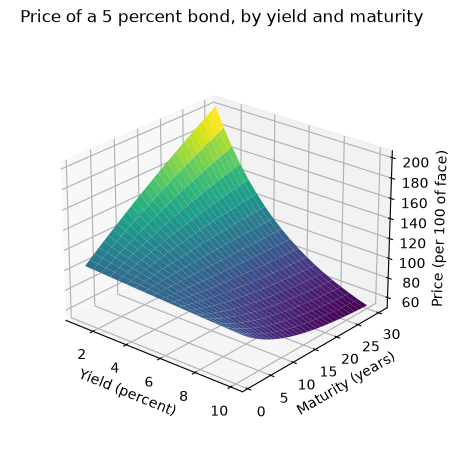

In [31]:
fig, ax = plt.subplots(figsize=(8, 5.5), subplot_kw={'projection': '3d'})

# plot_surface() takes the three tables. cmap= is the colour scale, as in the heatmaps.
ax.plot_surface(yield_grid, years_grid, price_grid, cmap='viridis')

ax.view_init(elev=25, azim=-50)
ax.set_box_aspect(None, zoom=0.85)

ax.set_title('Price of a 5 percent bond, by yield and maturity')
ax.set_xlabel('Yield (percent)')
ax.set_ylabel('Maturity (years)')
ax.set_zlabel('Price (per 100 of face)')

plt.show()

* The same 570 prices from one angle: flat at short maturities, and at 30 years running from 203.45 at the low-yield corner to 52.68 at the high-yield corner.

**When a 3D chart helps, and when it does not.** It helps when one quantity depends on two others and the reader can turn the chart: the shape of a surface, or the discovery that points lie on a sheet. On a printed page or a slide it cannot be turned, parts of it hide other parts, and heights are hard to read off. There, a heatmap of the same table, or a row of flat panels, reads better.

**Excel side by side.** An Excel chart is interactive in a smaller way: rest the pointer on a point or a bar and a tip shows the series name and the value. The stacked bars are Insert, Insert Column or Bar Chart, Stacked Column, drawn from a pivot table with `sector` in Rows, `grade` in Columns, and Sum of `market_value` in Values. One piece is `=SUMIFS(S2:S201, E2:E201, "Consumer", V2:V201, "High Yield") / 1000000`, which returns 19.02, with the market value in column S, the sector in column E, and the grade in column V.

For the third dimension, Excel has a 3-D Surface chart, drawn from a table with one variable down the side and the other across the top, and the `PRICE` worksheet function for the price of a bond. `=PRICE(DATE(2026,9,15), DATE(2056,9,15), 0.05, 0.1, 100, 2, 0)` prices the 5 percent bond 30 years from maturity at a yield of 10 percent, with 2 coupons a year and the 30/360 day count, and returns 52.68. In Excel the rate and the yield are entered as decimals. The check of the DTS column is `=MAX(ABS(P2:P201 - O2:O201 * M2:M201))`, with the DTS in column P, the spread duration in column O, and the OAS in column M. It returns 0.05, and in versions of Excel before dynamic arrays it is entered with Ctrl+Shift+Enter.

## 12.7 Customizing a Chart

The charts so far used the libraries' default look. A chart that goes into a meeting usually needs more: chosen colours, a sensible scale, numbers a reader can take in, a note on the point that matters, and a file. All of it is done with methods of `ax`, one line each. This section goes back to matplotlib and builds up one step at a time.

Q. Draw OAS against duration with the desk's own colour for each grade.

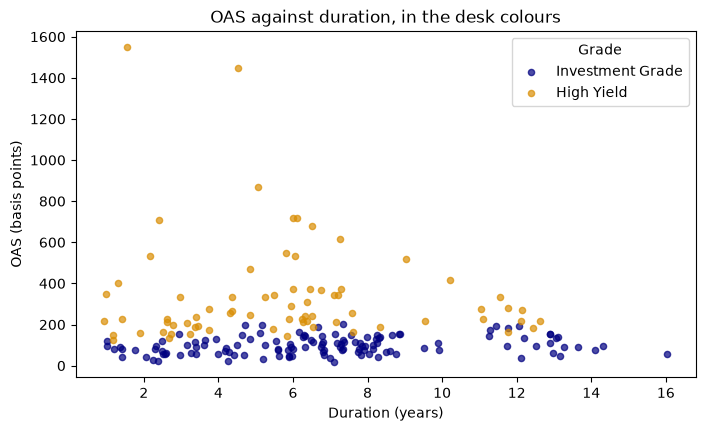

In [32]:
# a dictionary from week 1: each grade and its colour
# a colour can be a name that matplotlib knows or a hex code, as used on web pages
grade_colours = {'Investment Grade': 'navy', 'High Yield': '#d98e04'}

# figsize= sets the size of the figure, width then height, in inches
fig, ax = plt.subplots(figsize=(8, 4.5))

# one call to scatter() for each grade, with its own colour and its own name for the legend
# items() gives each grade together with its colour
for grade, colour in grade_colours.items():
    part = book[book['grade'] == grade]
    ax.scatter(part['duration'], part['oas'], color=colour, s=20, alpha=0.7, label=grade)

ax.legend(title='Grade')
ax.set_title('OAS against duration, in the desk colours')
ax.set_xlabel('Duration (years)')
ax.set_ylabel('OAS (basis points)')

plt.show()

* Navy for the 128 Investment Grade bonds and amber for the 72 High Yield bonds. The loop draws the two groups one after the other on the same axes.
* `color=` takes a name such as `'navy'` or `'black'`, or a hex code such as `'#d98e04'`. `s=` is the size of the points, and `alpha=` runs from 0, invisible, to 1, solid.
* Keeping the colours in one dictionary means every chart of the day gives a grade the same colour. A reader learns the colours once.
* The two widest bonds stretch the y axis to 1,551, so most of the chart is empty and the crowd is pressed against the bottom.

**Predict 3**

8 of the 200 bonds have an OAS above 600 basis points.

```
ax.set_ylim(0, 600)
```

What happens to those 8 bonds?

> A) They are deleted from `book`.
>
> B) They stay in `book` and are not drawn, with nothing on the chart to say so.
>
> C) matplotlib raises an error, because data falls outside the axis.

Decide, then run the cell.

Bonds with an OAS above 600 bp: 8


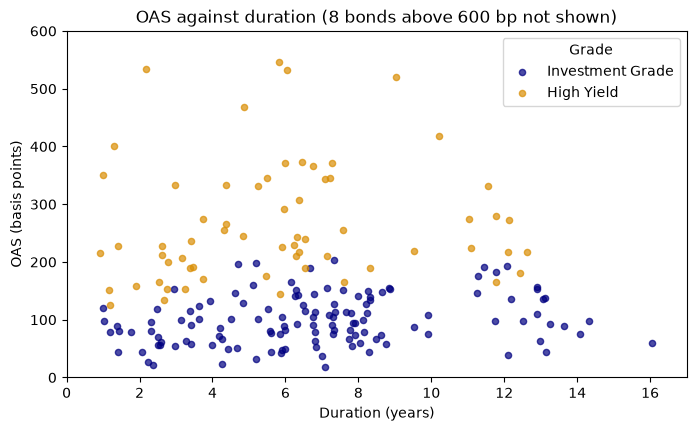

Rows in book after drawing: 200


In [33]:
print('Bonds with an OAS above 600 bp:', (book['oas'] > 600).sum())

fig, ax = plt.subplots(figsize=(8, 4.5))
for grade, colour in grade_colours.items():
    part = book[book['grade'] == grade]
    ax.scatter(part['duration'], part['oas'], color=colour, s=20, alpha=0.7, label=grade)

# set_ylim() sets the bottom and the top of the y axis. set_xlim() does the same for the x axis.
ax.set_ylim(0, 600)
ax.set_xlim(0, 17)

ax.legend(title='Grade')
# the title says what was left off
ax.set_title('OAS against duration (8 bonds above 600 bp not shown)')
ax.set_xlabel('Duration (years)')
ax.set_ylabel('OAS (basis points)')

plt.show()

print('Rows in book after drawing:', len(book))

* The answer is B. The table still has 200 rows. The axis is a window onto the data, and the 8 bonds above 600 basis points are outside the window.
* The lower part of the book is now readable: the navy band along the bottom, none above 204 basis points, and the amber points above it.
* matplotlib gives no sign that points were cut off. That is the chart maker's job, and here the title does it. A chart with a narrowed axis and no note is one of the easiest ways to mislead a reader without meaning to.

Q. Mark the median OAS of the book on the chart.

Median OAS: 135.5


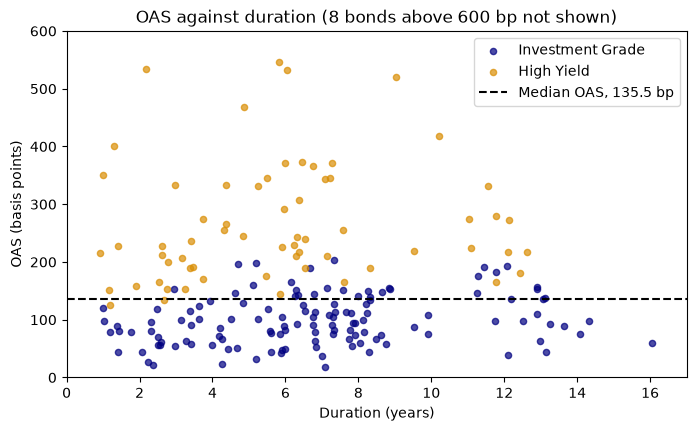

In [34]:
median_oas = book['oas'].median()
print('Median OAS:', median_oas)

fig, ax = plt.subplots(figsize=(8, 4.5))
for grade, colour in grade_colours.items():
    part = book[book['grade'] == grade]
    ax.scatter(part['duration'], part['oas'], color=colour, s=20, alpha=0.7, label=grade)

# axhline() draws a horizontal line at a value on the y axis
ax.axhline(median_oas, color='black', linestyle='--', label='Median OAS, 135.5 bp')

ax.set_ylim(0, 600)
ax.set_xlim(0, 17)

# loc= places the legend
ax.legend(loc='upper right')
ax.set_title('OAS against duration (8 bonds above 600 bp not shown)')
ax.set_xlabel('Duration (years)')
ax.set_ylabel('OAS (basis points)')

plt.show()

* The dashed line is at 135.5 basis points, the median from section 12.1. Half of the 200 bonds are below it and half above, including the 8 that are off the chart.
* A reference line gives the reader something to measure against. `axhline()` draws across the chart and `axvline()`, from yesterday, draws up it.
* The legend now has three entries. `loc='upper right'` places it, and other positions are `'upper left'`, `'upper center'`, `'lower right'`, and `'best'`, which lets matplotlib choose. Place a legend where it covers no data.

The next request is a note on the widest bond. This chart uses the full range again, so that the bond is on it.

Q. Point an arrow at the widest bond and label it.

Widest bond: FESR - duration 1.546 years, OAS 1551 bp


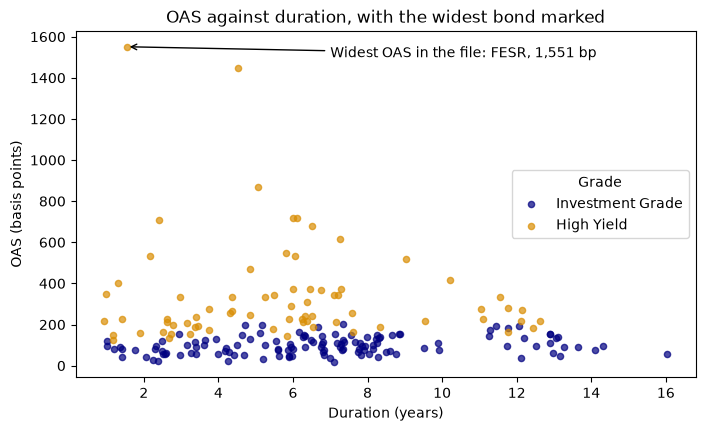

In [35]:
# the row with the highest OAS
widest = book.loc[book['oas'].idxmax()]
print('Widest bond:', widest['ticker'], '- duration', widest['duration'], 'years, OAS', widest['oas'], 'bp')

fig, ax = plt.subplots(figsize=(8, 4.5))
for grade, colour in grade_colours.items():
    part = book[book['grade'] == grade]
    ax.scatter(part['duration'], part['oas'], color=colour, s=20, alpha=0.7, label=grade)

# annotate() writes text and draws an arrow
# xy= is the point the arrow touches, and xytext= is where the text starts, both in data units
ax.annotate('Widest OAS in the file: ' + widest['ticker'] + ', 1,551 bp',
            xy=(widest['duration'], widest['oas']),
            xytext=(7, 1500),
            arrowprops={'arrowstyle': '->'})

ax.legend(title='Grade', loc='center right')
ax.set_title('OAS against duration, with the widest bond marked')
ax.set_xlabel('Duration (years)')
ax.set_ylabel('OAS (basis points)')

plt.show()

* The arrow touches the point at a duration of 1.546 years and an OAS of 1,551 basis points, the row with ticker FESR. The text starts at 7 years and 1,500 basis points, in an empty part of the chart.
* `xy=` took its two numbers from the row, not from typed values, so the arrow stays on the bond if the file changes.
* The note describes a row of the file. It says which bond has the highest number, and nothing about the bond.

`annotate()` needs to know where to point.

TypeError: Axes.annotate() missing 1 required positional argument: 'xy'

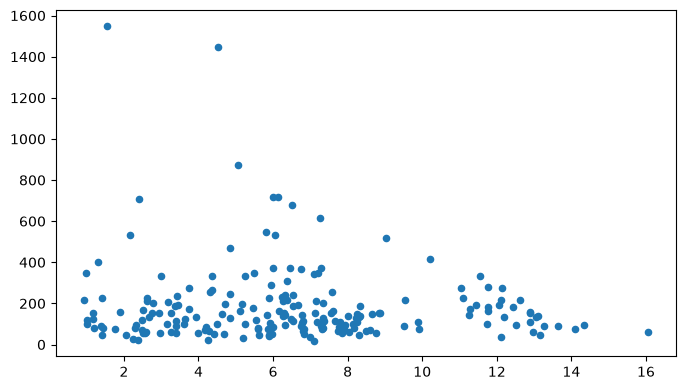

In [36]:
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.scatter(book['duration'], book['oas'], s=20)

# the text, and no point for it
ax.annotate('Widest OAS in the file')

plt.show()

* A `TypeError`: `Axes.annotate() missing 1 required positional argument: 'xy'`. The same kind of error as the missing degree in section 12.2. The text was given and the point was not.
* The chart under the error has its points and no note. The scatter on line 2 ran before the error on line 5.
* The fix is to pass `xy=`, as in the cell before this one.

Large numbers are hard to read on an axis.

Q. How much market value is in each rating bucket, in dollars?

bucket
AAA      8200605.0
AA      13048305.0
A      148505040.0
BBB    151163415.0
BB     113754240.0
B       43595535.0
CCC     12552075.0
Name: market_value, dtype: float64


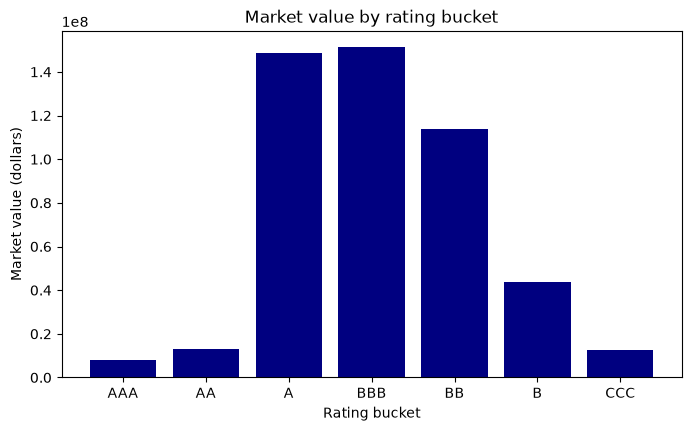

In [37]:
# total market value of each bucket in dollars, in credit order
value_by_bucket = book.groupby('bucket')['market_value'].sum().loc[bucket_order]
print(value_by_bucket)

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.bar(value_by_bucket.index, value_by_bucket.values, color='navy')

ax.set_title('Market value by rating bucket')
ax.set_xlabel('Rating bucket')
ax.set_ylabel('Market value (dollars)')

plt.show()

* The BBB bar is the tallest at 151,163,415 dollars and the A bar is close behind at 148,505,040.
* Look at the y axis. The ticks read 0.0 to 1.4, and a small `1e8` sits at the top left: matplotlib has divided the numbers by 100,000,000 and left a note. It is correct and easy to misread.

Q. Show the dollars in full, with thousands separators.

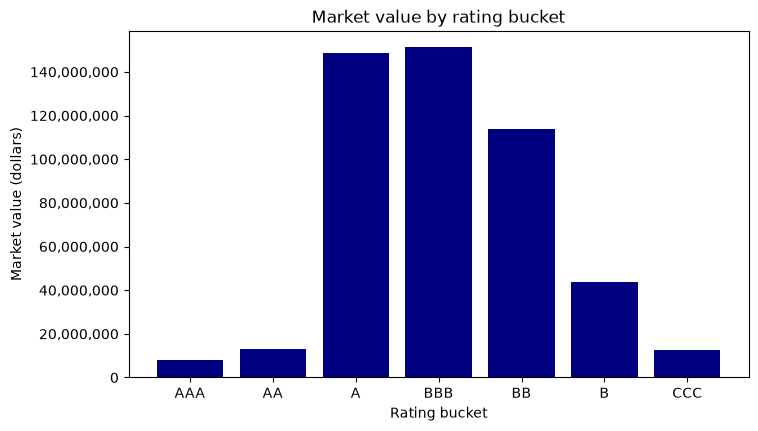

In [38]:
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.bar(value_by_bucket.index, value_by_bucket.values, color='navy')

# the format of the numbers on the y axis. Inside the braces, x stands for the number,
# the comma asks for thousands separators, and .0f for no decimal places.
ax.yaxis.set_major_formatter('{x:,.0f}')

ax.set_title('Market value by rating bucket')
ax.set_xlabel('Rating bucket')
ax.set_ylabel('Market value (dollars)')

plt.show()

* The same seven bars. The axis now reads 20,000,000, 40,000,000, and so on up to 140,000,000, and the `1e8` is gone.
* `ax.yaxis` is the y axis itself, and `set_major_formatter()` sets how its tick labels are written. `ax.xaxis` works the same way.

Q. Show each bucket as a percentage of the book's market value.

bucket
AAA     1.7
AA      2.7
A      30.3
BBB    30.8
BB     23.2
B       8.9
CCC     2.6
Name: market_value, dtype: float64


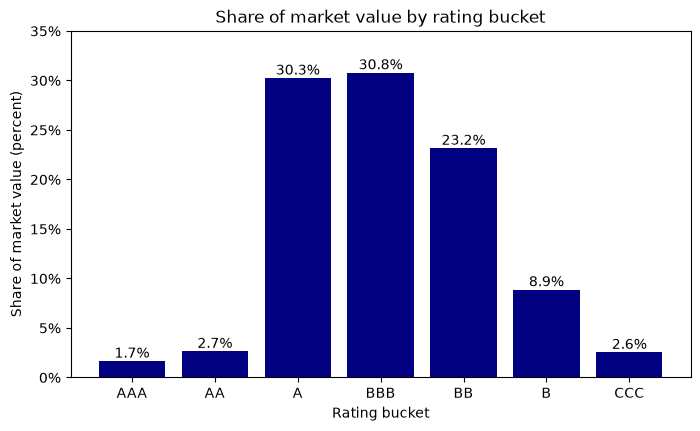

In [39]:
# PercentFormatter writes axis numbers as percentages
from matplotlib.ticker import PercentFormatter

# each bucket as a percentage of the total
share_by_bucket = value_by_bucket / value_by_bucket.sum() * 100
print(share_by_bucket.round(1))

fig, ax = plt.subplots(figsize=(8, 4.5))
bars = ax.bar(share_by_bucket.index, share_by_bucket.values, color='navy')

# write each value above its bar: one decimal place and a percent sign
ax.bar_label(bars, fmt='%.1f%%')

# xmax=100 says the values are already percentages. decimals=0 shows whole numbers on the axis.
ax.yaxis.set_major_formatter(PercentFormatter(xmax=100, decimals=0))

# room above the tallest bar for its label
ax.set_ylim(0, 35)

ax.set_title('Share of market value by rating bucket')
ax.set_xlabel('Rating bucket')
ax.set_ylabel('Share of market value (percent)')

plt.show()

* BBB is 30.8 percent of the book's market value, A is 30.3 percent, and BB is 23.2 percent. The seven shares add up to 100.
* The axis reads 0% to 35%, and each bar carries its own figure, so the reader does not have to judge heights against the axis.
* In `'%.1f%%'`, the `%.1f` is the number with one decimal place and the doubled `%%` is a single percent sign.
* If the values were fractions such as 0.308, the formatter would be `PercentFormatter(xmax=1)`.

Two charts side by side let a reader compare groups without colour.

Q. Draw OAS against duration in two panels, one for each grade.

Highest OAS, Investment Grade: 204  High Yield: 1551


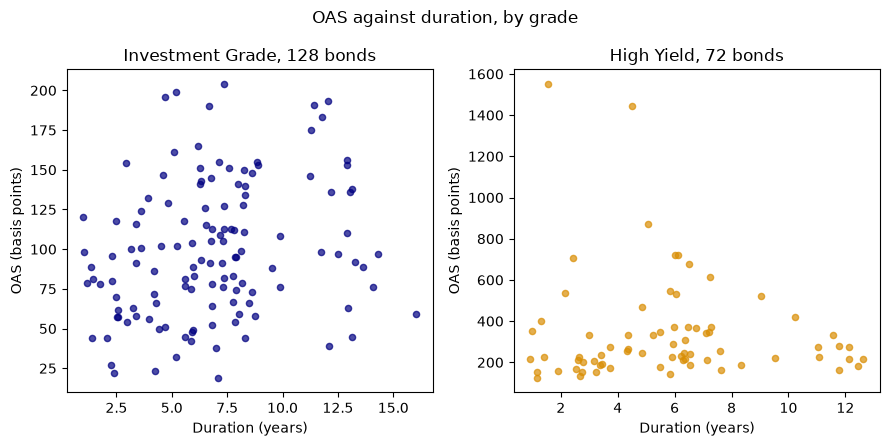

In [40]:
ig = book[book['grade'] == 'Investment Grade']
hy = book[book['grade'] == 'High Yield']
print('Highest OAS, Investment Grade:', ig['oas'].max(), ' High Yield:', hy['oas'].max())

# 1 row and 2 columns of axes on one figure. axes is now a list of two.
fig, axes = plt.subplots(1, 2, figsize=(9, 4.5))

# the left panel is axes[0]
axes[0].scatter(ig['duration'], ig['oas'], color=grade_colours['Investment Grade'], s=20, alpha=0.7)
axes[0].set_title('Investment Grade, 128 bonds')
axes[0].set_xlabel('Duration (years)')
axes[0].set_ylabel('OAS (basis points)')

# the right panel is axes[1]
axes[1].scatter(hy['duration'], hy['oas'], color=grade_colours['High Yield'], s=20, alpha=0.7)
axes[1].set_title('High Yield, 72 bonds')
axes[1].set_xlabel('Duration (years)')
axes[1].set_ylabel('OAS (basis points)')

# a title for the whole figure, and tight_layout() to stop the panels touching
fig.suptitle('OAS against duration, by grade')
fig.tight_layout()

plt.show()

* Two panels on one figure. The Investment Grade panel shows the mild upward tilt of section 12.2, which was hard to see when those points were squeezed along the bottom of a shared chart.
* Read the two y axes before comparing. The left one stops just above 204 basis points and the right one runs past 1,551. Each panel has its own scale, so the two clouds look equally tall and are not.
* `plt.subplots(1, 2, sharey=True)` gives both panels the same y axis. That is the honest choice when the reader is meant to compare heights, and the separate scales are the useful choice when each panel is read for its own shape. Say which was used.
* With more than one axes, `plt.subplots()` returns them as an array, and each panel is reached by its position: `axes[0]`, `axes[1]`.

Every chart of the day should look as if it came from the same desk. A function, from week 1, holds the look in one place.

Q. Write a function that gives any chart the desk's style, and use it.

bucket
AAA     21.00
AA      37.62
A       79.41
BBB    127.82
BB     226.22
B      503.33
CCC    858.00
Name: oas, dtype: float64


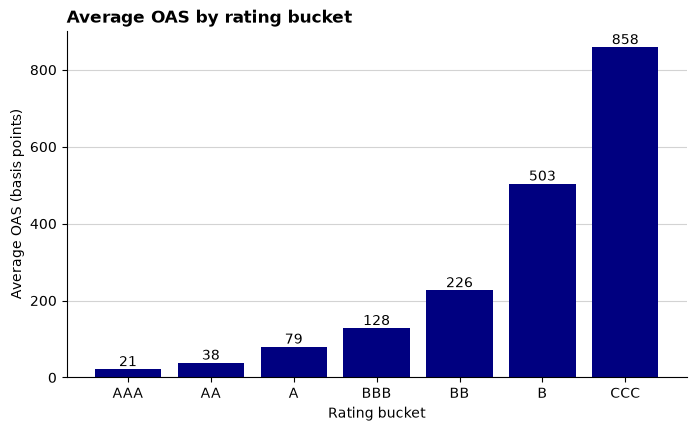

In [41]:
def desk_style(ax, title, xlabel, ylabel):
    # the title, at the left and in bold, and the two axis labels
    ax.set_title(title, loc='left', fontweight='bold')
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    # remove the top and right edges of the box around the plot
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    # faint horizontal grid lines, drawn behind the bars
    ax.grid(axis='y', color='lightgrey')
    ax.set_axisbelow(True)


# the average OAS of each bucket, in credit order
mean_by_bucket = book.groupby('bucket')['oas'].mean().loc[bucket_order]
print(mean_by_bucket.round(2))

fig, ax = plt.subplots(figsize=(8, 4.5))
bars = ax.bar(mean_by_bucket.index, mean_by_bucket.values, color='navy')
ax.bar_label(bars, fmt='%.0f')

# one line applies the whole style
desk_style(ax, 'Average OAS by rating bucket', 'Rating bucket', 'Average OAS (basis points)')

plt.show()

* Yesterday's bar chart of average OAS by bucket, from 21 basis points for AAA to 858 for CCC, with BBB at 127.82, in the desk's style: navy bars, a bold title at the left, no box at the top and right, and faint grid lines behind the bars.
* The function takes the axes as its first argument and calls the same methods used all day. Any chart can be passed to it, and a change to the style is made once, inside the function.
* `ax.spines` holds the four edges of the plot, by name.

The last step is a file.

Q. Save the chart as a picture, check that it is there, then tidy up.

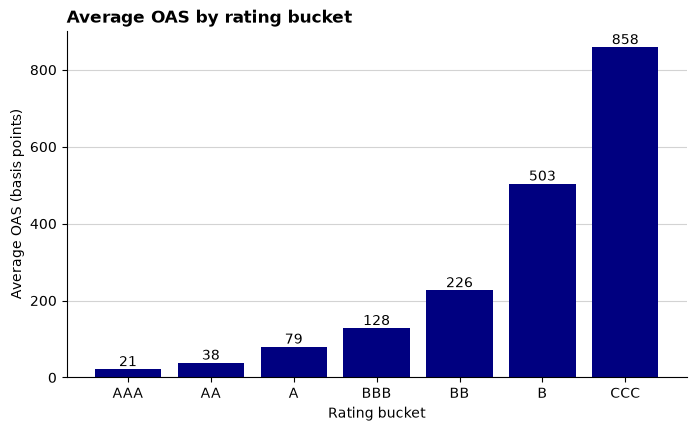

File exists: True
File exists after removing it: False


In [42]:
fig, ax = plt.subplots(figsize=(8, 4.5))
bars = ax.bar(mean_by_bucket.index, mean_by_bucket.values, color='navy')
ax.bar_label(bars, fmt='%.0f')
desk_style(ax, 'Average OAS by rating bucket', 'Rating bucket', 'Average OAS (basis points)')

# savefig() writes the figure to a file in the working folder. The ending of the name sets the type.
# dpi= is the dots per inch: 150 is sharp enough for a slide. bbox_inches='tight' trims the empty margin.
fig.savefig('average_oas_by_bucket.png', dpi=150, bbox_inches='tight')

plt.show()

print('File exists:', os.path.exists('average_oas_by_bucket.png'))

# os.remove() deletes the file, so the folder is left as it was found
os.remove('average_oas_by_bucket.png')
print('File exists after removing it:', os.path.exists('average_oas_by_bucket.png'))

* The chart was drawn, saved as `average_oas_by_bucket.png`, found in the working folder, and deleted again. In your own work, leave out the `os.remove()` line and the file stays.
* `savefig()` is a method of the figure, not of the axes: the file holds the whole picture. Call it before `plt.show()`.
* A name ending in `.png` gives a picture for a slide or an email. A name ending in `.pdf` gives a file that stays sharp at any size, for print.
* The figure-level seaborn charts are saved the same way, through their figure: `grid.figure.savefig(...)`.

**Excel side by side.** Each step of this section has a place in Excel's Format pane, reached by double-clicking the part of the chart to change.

| Job | matplotlib | Excel |
| --- | --- | --- |
| Colour of a series | `color='navy'` | Format Data Series, Fill & Line |
| Size of the chart | `figsize=(8, 4.5)` | drag a corner, or Format Chart Area, Size |
| Axis limits | `ax.set_ylim(0, 600)` | Format Axis, Axis Options, Bounds: Minimum and Maximum |
| Thousands separators | `ax.yaxis.set_major_formatter('{x:,.0f}')` | Format Axis, Number, Format Code `#,##0` |
| Percent on an axis | `PercentFormatter(xmax=100)` | Format Axis, Number, Percentage, on values held as fractions |
| Value on every bar | `ax.bar_label(bars)` | Chart Elements, Data Labels |
| Note on one point | `ax.annotate(...)` | click the point twice so that it alone is selected, then right-click, Add Data Label |
| Reference line | `ax.axhline(135.5)` | a second series that holds the same value in every row |
| Legend position | `ax.legend(loc='upper right')` | Chart Elements, Legend, then Top, Bottom, Left, or Right |
| Charts side by side | `plt.subplots(1, 2)` | two charts placed next to each other on the sheet |
| One style for every chart | a function such as `desk_style()` | right-click a finished chart, Save as Template |
| Save as a picture | `fig.savefig('name.png')` | right-click the chart, Save as Picture |

The numbers behind this section's charts, with the OAS in column M, the ticker in column C, the market value in column S, and the bucket in column U:

| Number | Python | Excel | Result |
| --- | --- | --- | --- |
| Median OAS | `book['oas'].median()` | `=MEDIAN(M2:M201)` | 135.5 |
| Bonds above 600 bp | `(book['oas'] > 600).sum()` | `=COUNTIF(M2:M201, ">600")` | 8 |
| Ticker of the widest bond | `book.loc[book['oas'].idxmax(), 'ticker']` | `=INDEX(C2:C201, MATCH(MAX(M2:M201), M2:M201, 0))` | FESR |
| BBB share of market value | `share_by_bucket['BBB']` | `=SUMIF(U2:U201, "BBB", S2:S201) / SUM(S2:S201)` | 30.8% |

In Excel the choices are made in panes and stay with that one chart, or with a template. In matplotlib they are lines of code, so the chart for next month's file comes out the same without a click.

## 12.8 Choosing a Chart

Yesterday's table had seven charts. Today adds these.

| The question | Chart | Function | Nearest in Excel |
| --- | --- | --- | --- |
| How much does y change with x, on a straight line? | Regression plot | `np.polyfit()`, `sns.regplot()`, `sns.lmplot()` | Scatter with a Linear trendline, `SLOPE`, `INTERCEPT`, `RSQ` |
| Two columns together, and each on its own? | Joint plot | `sns.jointplot()` | a Scatter and two Histograms |
| What shape does each group have? | Violin plot | `sns.violinplot()` | Box and Whisker |
| Where is every bond of each group? | Strip plot, swarm plot | `sns.stripplot()`, `sns.swarmplot()` | Box and Whisker with Show inner points |
| The same chart for each value of another column? | Panels | `sns.catplot(col=...)`, `plt.subplots(1, 2)` | one chart per group |
| Which bond is that point? | Interactive chart | `px.scatter()`, `px.bar()` | the tip shown when the pointer rests on a point |
| How does one quantity depend on two others? | 3D scatter, surface | `px.scatter_3d()`, `go.Surface()` | 3-D Surface chart |

And the habits of a chart that leaves the desk:

* Print the slope, the intercept, and R squared next to any fitted line, with their units. A line can be fitted to any cloud.
* A fitted line describes the file it was fitted on. It is not a forecast.
* Check the ends of a smoothed shape against the lowest and the highest value.
* When an axis is narrowed, say on the chart what was left off.
* When panels have different scales, say so.
* One set of colours and one style for the whole pack, held in a dictionary and a function.
* Use a 3D chart where the reader can turn it. On paper, use a heatmap or flat panels.
* A saved chart can carry data. Treat the file as you would the spreadsheet behind it.

## You Can Now

* Fit a straight line with `np.polyfit()`, state its slope and intercept with units, and draw it with its band using `sns.regplot()` and `sns.lmplot()`.
* Say what R squared measures, and match the Python results to `SLOPE`, `INTERCEPT`, and `RSQ` in Excel.
* Show two columns and their distributions together with a joint plot.
* Show the shape of each group with a violin plot and every bond with a strip or swarm plot, and split a chart into panels with `catplot()`.
* Draw an interactive chart with plotly, read a bond off it, and save it as a web page.
* Draw three columns as a 3D scatter and a formula as a surface, and say when a 3D chart is the wrong choice.
* Customize a matplotlib chart: colours, axis limits, number formats, a reference line, an annotation, a legend, and panels side by side.
* Give every chart one style with a function, and save a chart to a file with `savefig()`.

The next notebook puts these charts to work. It is a first exploratory analysis of a holdings file that has problems in it: missing values, duplicates, and numbers that do not look right.

## Exercises

The exercises use the same 200 bonds and ask about columns and pairs the lesson did not chart: the rating score, the price, the sectors, and the DTS. One of them asks for an interactive chart. The issuers are invented, and every answer describes the data and is not a view.

Each exercise asks for a chart and for one or two numbers that the chart should agree with. Replace each `...` with your own code, draw the chart in the same cell or a new one, then run the check cell. Give every chart a title and axis labels with units. Worked answers are in the solutions notebook in this folder.

Run the next cell first. It imports the libraries, loads fresh copies of the two tables, rebuilds `book` and `bucket_order`, and defines `check`, a small function that marks your answers. It prints the shape of the book, (200, 22), and the seven buckets in credit order.

In [43]:
import os

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import plotly.express as px
import seaborn as sns
from matplotlib.ticker import PercentFormatter


def check(label, answer, expected):
    """Compare an exercise answer to the expected value and print the result."""
    if answer is ...:
        print(label + ': not attempted yet')
        return
    if isinstance(expected, list):
        # a list of values: the same values in the same order
        correct = list(answer) == expected
    elif isinstance(expected, float):
        # single numbers with a decimal point: within a small tolerance
        correct = abs(answer - expected) < 0.000001
    else:
        correct = answer == expected
    if correct:
        print(label + ': correct')
    else:
        print(label + ': not yet. You have', answer)


# fresh copies of the two tables. In Colab they are read from GitHub.
if os.path.exists('../../../data/holdings.csv'):
    data_folder = '../../../data/'
else:
    data_folder = 'https://raw.githubusercontent.com/lenamonj/python-fixed-income/main/data/'

holdings = pd.read_csv(data_folder + 'holdings.csv')
ratings = pd.read_csv(data_folder + 'ratings.csv')

# the book, rebuilt: the holdings with the score, bucket, and grade of each rating
book = pd.merge(holdings, ratings, on='rating', how='left')
bucket_order = ratings.sort_values('score')['bucket'].unique().tolist()

print(book.shape)
print(bucket_order)

(200, 22)
['AAA', 'AA', 'A', 'BBB', 'BB', 'B', 'CCC']


### Exercise 1

Q. The `score` column numbers the ratings from 1 for AAA to 18 for CCC. Fit a straight line of `oas` on `score` with `np.polyfit()`, and draw it with `sns.regplot()`. What are the slope and the intercept, each rounded to 2 decimal places? Store them in **ex1_slope** and **ex1_intercept**.

In [44]:
ex1_slope = ...
ex1_intercept = ...

In [45]:
check('Exercise 1 slope', ex1_slope, 42.45)
check('Exercise 1 intercept', ex1_intercept, -211.63)

Exercise 1 slope: not attempted yet
Exercise 1 intercept: not attempted yet


### Exercise 2

Q. Draw a strip plot of `price` with one column for each rating bucket, in credit order. Set `np.random.seed(0)` first. What is the lowest price in the file, and which bucket is that bond in? Store the answers in **ex2_low** and **ex2_bucket**. The method `idxmin()` returns the row label of the smallest value in a Series.

In [46]:
ex2_low = ...
ex2_bucket = ...

In [47]:
check('Exercise 2 lowest price', ex2_low, 62.045)
check('Exercise 2 bucket', ex2_bucket, 'B')

Exercise 2 lowest price: not attempted yet
Exercise 2 bucket: not attempted yet


### Exercise 3

Q. Work out each sector's share of the book's market value, in percent. Draw the shares as horizontal bars with the largest at the top, a percent format on the x axis, and the value written on each bar. Which sector has the largest share, and what is it, rounded to 1 decimal place? Store the answers in **ex3_sector** and **ex3_share**.

In [48]:
ex3_sector = ...
ex3_share = ...

In [49]:
check('Exercise 3 sector', ex3_sector, 'Materials')
check('Exercise 3 share', ex3_share, 14.6)

Exercise 3 sector: not attempted yet
Exercise 3 share: not attempted yet


### Exercise 4

Q. Draw an interactive scatter plot with plotly: `duration` on the x axis and `dts` on the y axis, coloured by grade, with the issuer name as the heading of the hover box and the ticker and rating inside it. Point at the highest point on the chart. What is that bond's ticker, and what is its DTS? Confirm both with code, using `idxmax()`, and store them in **ex4_ticker** and **ex4_dts**.

In [50]:
ex4_ticker = ...
ex4_dts = ...

In [51]:
check('Exercise 4 ticker', ex4_ticker, 'CLDB')
check('Exercise 4 DTS', ex4_dts, 6525.8)

Exercise 4 ticker: not attempted yet
Exercise 4 DTS: not attempted yet


### Exercise 5: AI check

You ask an AI assistant to fit a straight line of yield on coupon across the book, draw it over the bonds, and say how much yield goes with each extra point of coupon. It gives you the code below. It was written for this course in the style of an AI assistant's answer. It contains one bug.

Q. Read the code before you run it. What slope should it report? The lesson worked it out in section 12.2. Then run the code. Does the answer agree with you?

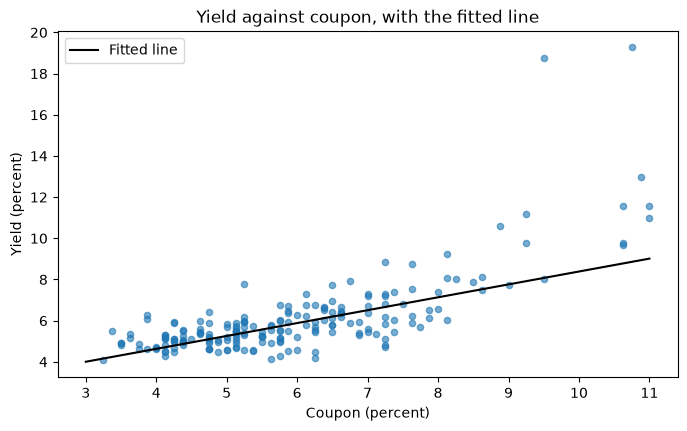

Each extra point of coupon goes with 0.63 points of yield


In [52]:
# written for this course in the style of an AI assistant's answer. It contains one bug.
# straight-line fit of yield on coupon
slope, intercept = np.polyfit(book['yield_pct'], book['coupon'], 1)

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.scatter(book['coupon'], book['yield_pct'], s=20, alpha=0.6)

# the fitted line between a coupon of 3 percent and 11 percent
line_x = np.array([3, 11])
ax.plot(line_x, intercept + slope * line_x, color='black', label='Fitted line')

ax.legend()
ax.set_title('Yield against coupon, with the fitted line')
ax.set_xlabel('Coupon (percent)')
ax.set_ylabel('Yield (percent)')

plt.show()

ex5_slope = round(slope, 2)
print('Each extra point of coupon goes with', ex5_slope, 'points of yield')

Q. Find the bug and fix the code in the cell above, so that the line is the fit of yield on coupon and **ex5_slope** holds the right answer.

In [53]:
check('Exercise 5 slope', ex5_slope, 0.88)

Exercise 5 slope: not yet. You have 0.63
